# Remap AVISO to tx2_3

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf
import numpy as np
import datetime
import matplotlib.pyplot as plt
import warnings

# Suppress RuntimeWarnings globally
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [4]:
def weighted_temporal_mean(ds, var):
    """
    weight by days in each month
    """
    # Determine the month length
    month_length = ds.time.dt.days_in_month

    # Calculate the weights
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()

    # Make sure the weights in each year add up to 1
    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0)

    # Subset our dataset for our variable
    obs = ds[var]

    # Setup our masking for nan values
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)

    # Calculate the numerator
    obs_sum = (obs * wgts).resample(time="YS").sum(dim="time")

    # Calculate the denominator
    ones_out = (ones * wgts).resample(time="YS").sum(dim="time")

    # Return the weighted average
    return obs_sum / ones_out

In [5]:
fname = '../mesh/tx2_3v3_grid.nc'
ds_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b', 'nx' : 'xh', 'ny' : 'yh',
                                        'depth' : 'z_l', 'tmask':'mask'})
ds_out

<xarray.Dataset> Size: 42MB
Dimensions:  (yh: 480, xh: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: yh, xh, nxp, nyp
Data variables: (12/20)
    lon      (yh, xh) float64 2MB ...
    lat      (yh, xh) float64 2MB ...
    ulon     (yh, nxp) float64 2MB ...
    ulat     (yh, nxp) float64 2MB ...
    vlon     (nyp, xh) float64 2MB ...
    vlat     (nyp, xh) float64 2MB ...
    ...       ...
    tarea    (yh, xh) float64 2MB ...
    mask     (yh, xh) float64 2MB ...
    angle    (yh, xh) float64 2MB ...
    z_l      (yh, xh) float64 2MB ...
    ar       (yh, xh) float64 2MB ...
    egs      (yh, xh) float64 2MB ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

In [6]:
def regrid_tracer(fld, ds_in, ds_out, method='bilinear'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    fld_out = regrid(ds_in[fld])#[0,0,:]#.where(ds_in.lat>ds_out.geolat.min())
    return fld_out

### Averaged Sea Level Anomalies

In [7]:
infile = '/glade/campaign/cgd/oce/datasets/obs/aviso/mean_sea_level_anomaly/dt_global_allsat_msla_h_y*nc'
ds_in = xr.open_mfdataset(infile)
ds_in

/glade/derecho/scratch/gmarques/tmp/ipykernel_48164/16146052.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_in = xr.open_mfdataset(infile)


<xarray.Dataset> Size: 3GB
Dimensions:           (time: 312, nv: 2, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 2kB 1993-01-15 ... 2018-12-15
  * nv                (nv) int32 8B 0 1
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Data variables:
    climatology_bnds  (time, nv) datetime64[ns] 5kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds          (time, lat, nv) float32 2MB dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds          (time, lon, nv) float32 4MB dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    crs               (time) int32 1kB -2147483647 -2147483647 ... -2147483647
    sla               (time, lat, lon) float64 3GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/39)
    cdm_data_type:                   Grid
    comment:                         Monthly Mean of Sea Level Anomalies refe...
    date_issued:                     2018-02-13 16:54:24Z
    time_coverage_resolution:        P1M
    creator_email:                   aviso@altimetry.fr
    product_version:                 5.10
    ...                              ...
    geospatial_vertical_min:         0.0
    geospatial_vertical_max:         0.0
    geospatial_lat_units:            degrees_north
    geospatial_lon_units:            degrees_east
    geospatial_lat_resolution:       0.25
    geospatial_lon_resolution:       0.25

In [8]:
sla = regrid_tracer('sla', ds_in, ds_out).rename('sla')
sla

<xarray.DataArray 'sla' (time: 312, yh: 480, xh: 540)> Size: 647MB
dask.array<sum-aggregate, shape=(312, 480, 540), dtype=float64, chunksize=(1, 480, 540), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 1993-01-15 1993-02-15 ... 2018-12-15
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  bilinear

In [9]:
# add coordinates
sla = sla.assign_coords(geolat=ds_out.lat, geolon=ds_out.lon)
sla

<xarray.DataArray 'sla' (time: 312, yh: 480, xh: 540)> Size: 647MB
dask.array<sum-aggregate, shape=(312, 480, 540), dtype=float64, chunksize=(1, 480, 540), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 1993-01-15 1993-02-15 ... 2018-12-15
    geolat   (yh, xh) float64 2MB -81.56 -81.56 -81.56 ... 50.27 50.11 49.99
    geolon   (yh, xh) float64 2MB -286.7 -286.0 -285.3 ... 72.97 72.98 73.0
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  bilinear

##### Visual inspection
Make sure original and remapped plots look similar.

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/dask/config.py:786: FutureWarning: Dask configuration key 'allowed-failures' has been deprecated; please use 'distributed.scheduler.allowed-failures' instead
  warnings.warn(


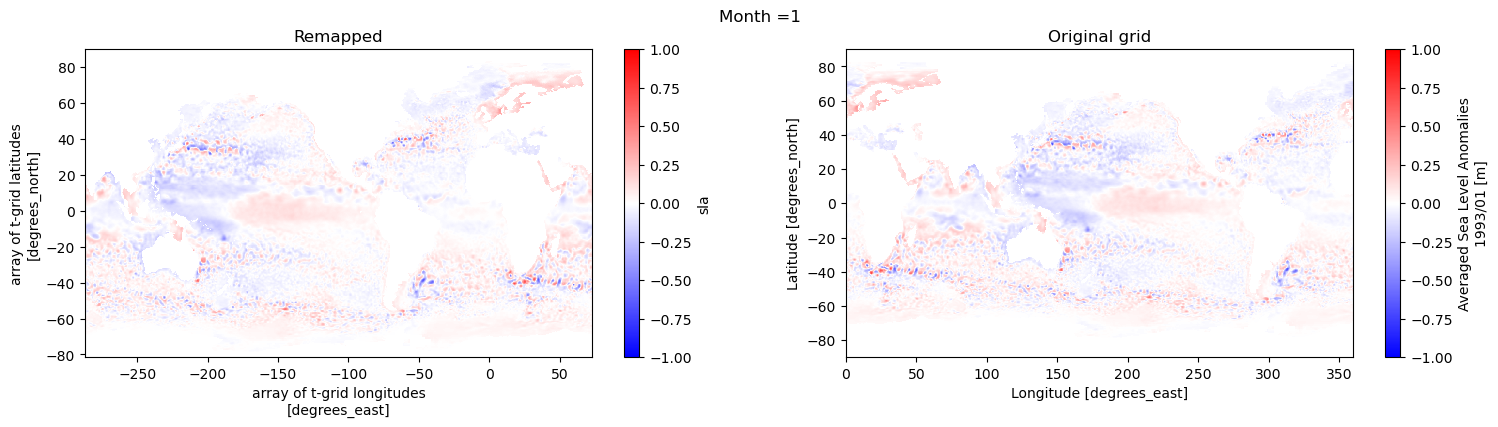

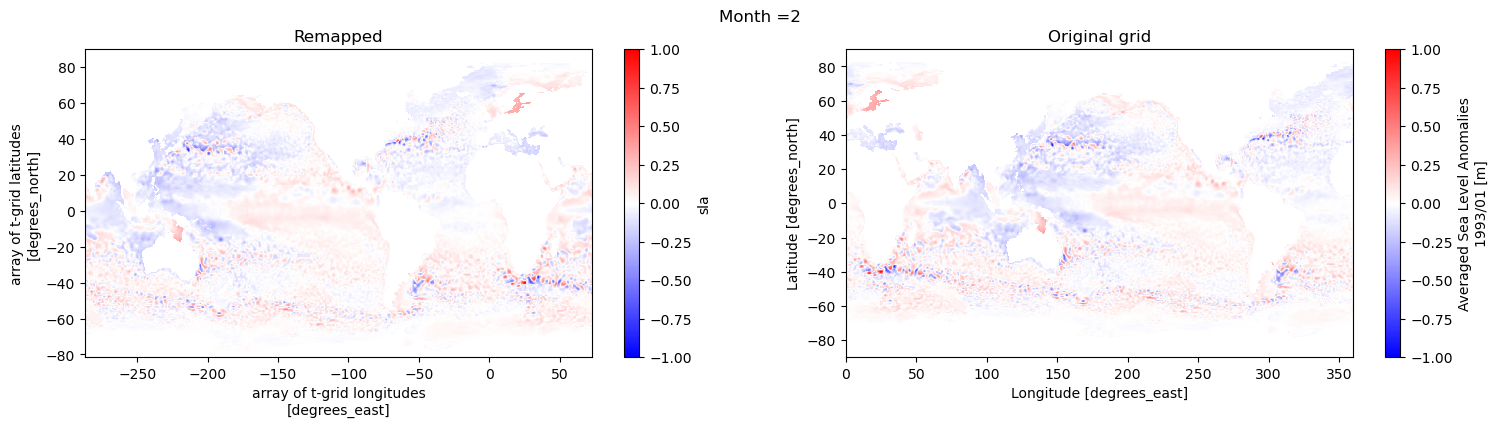

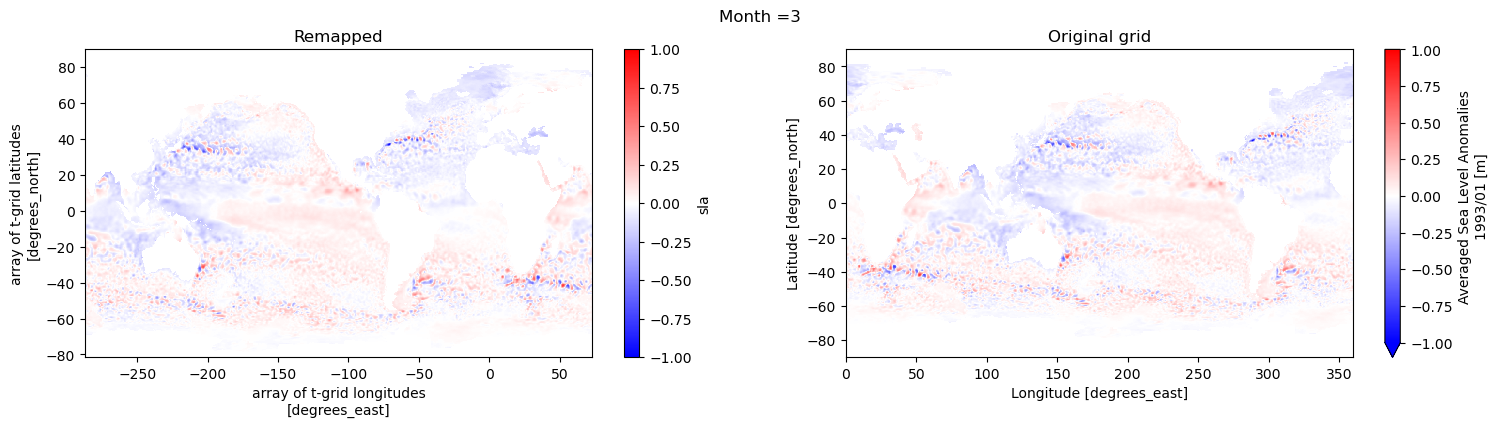

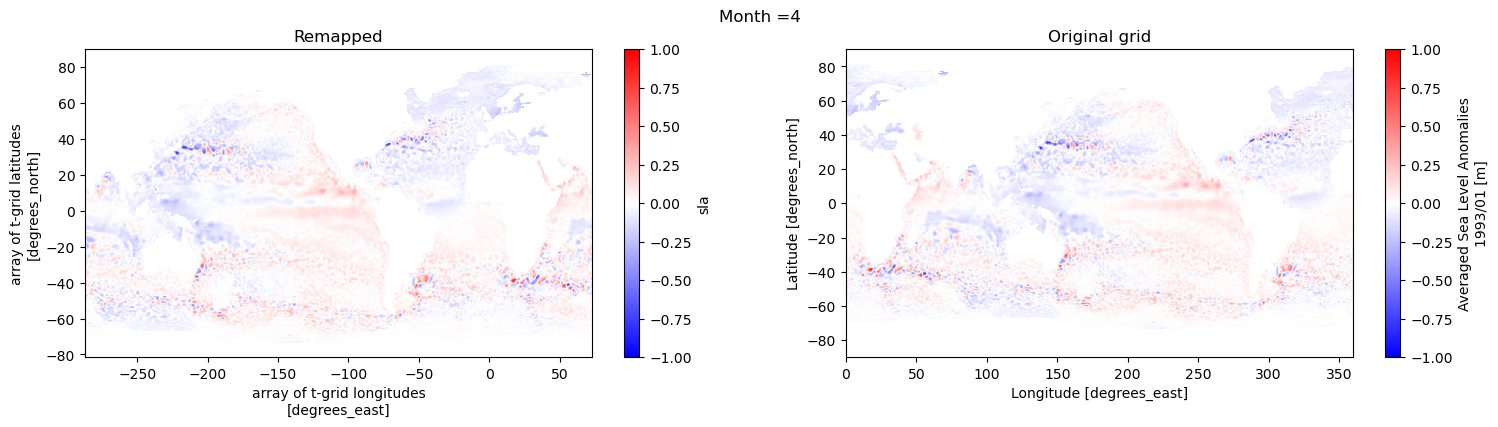

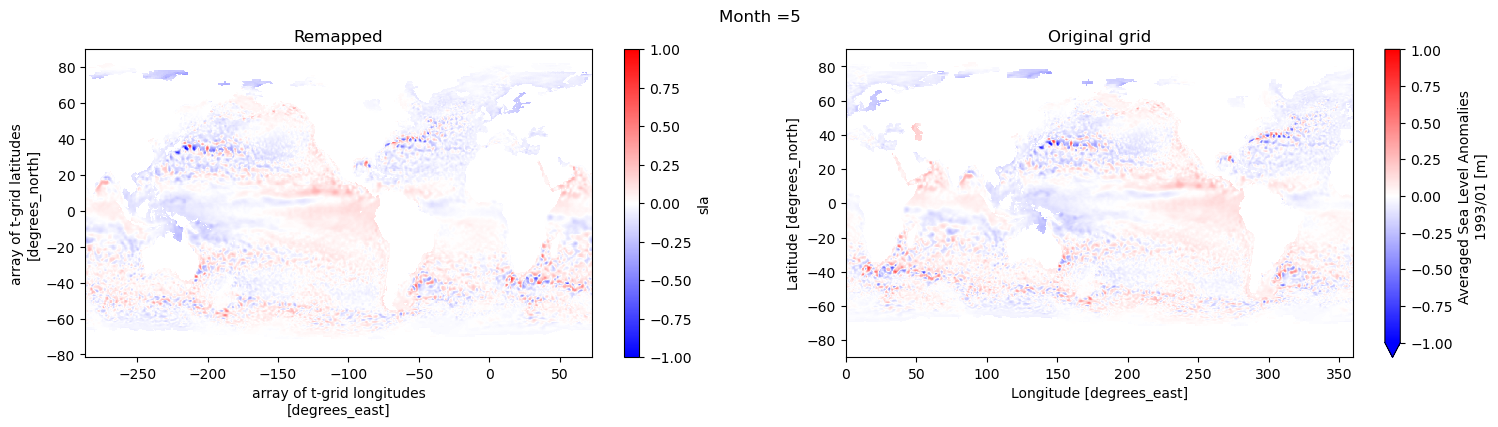

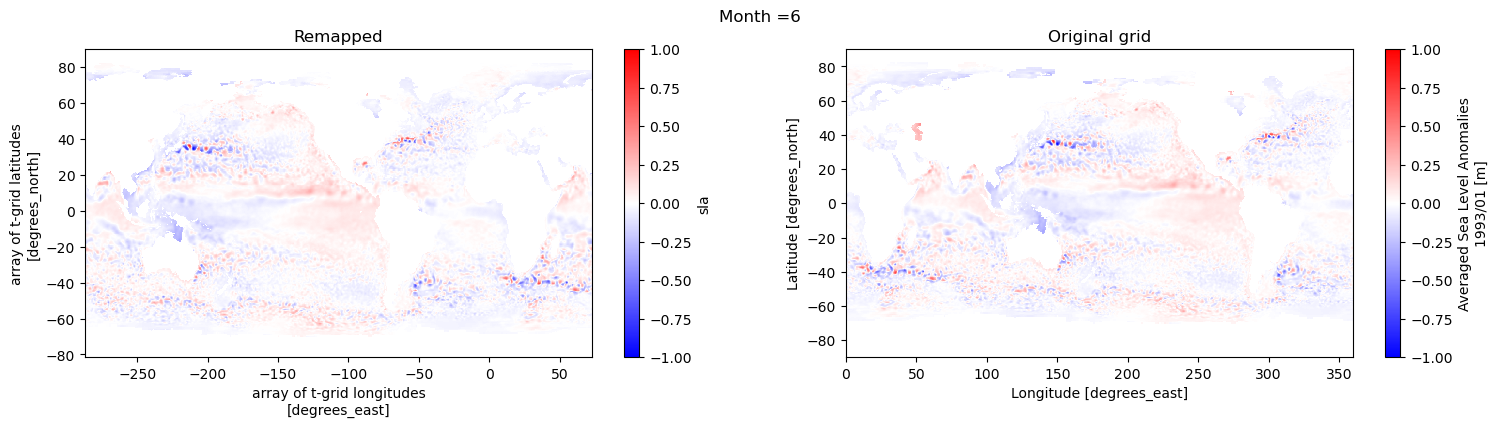

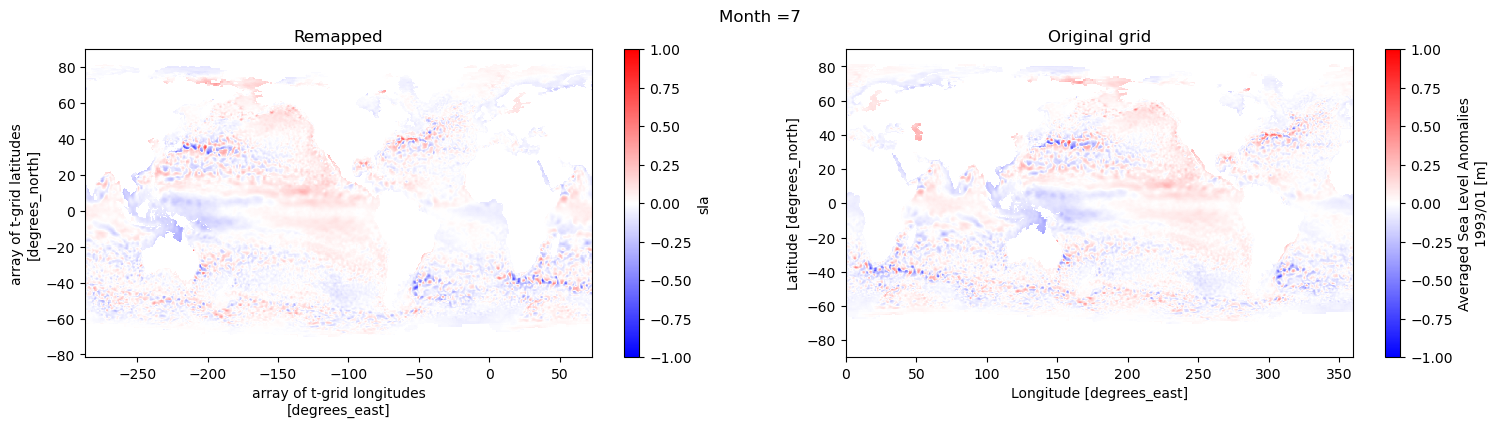

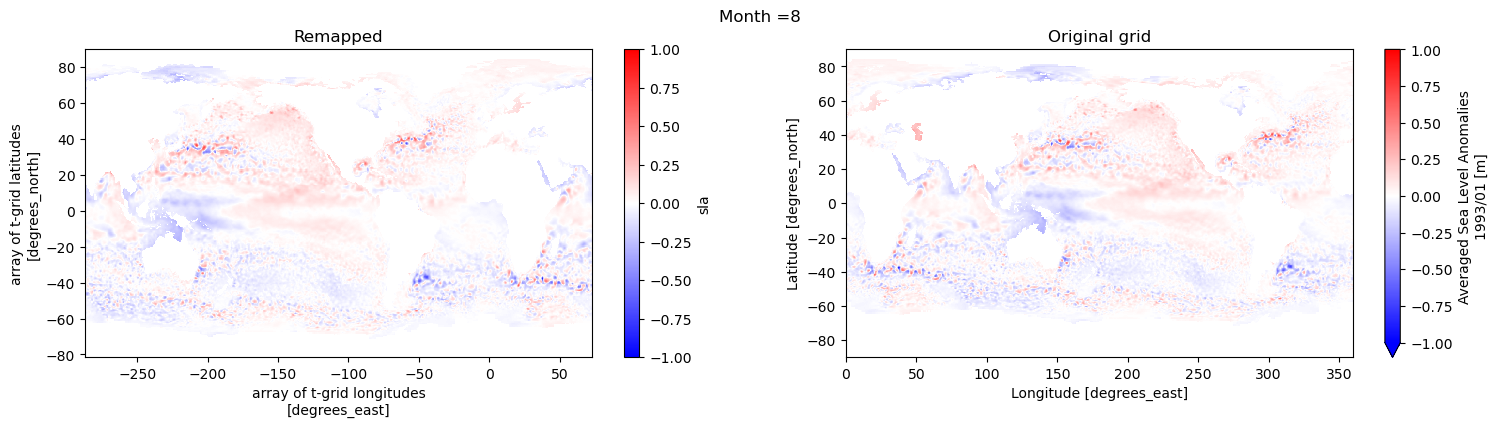

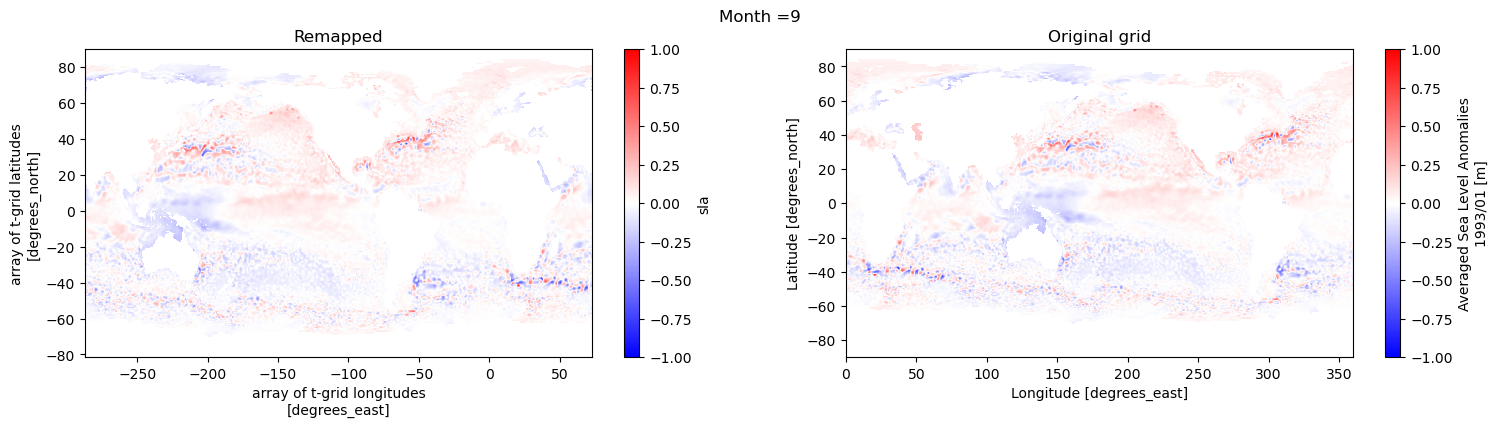

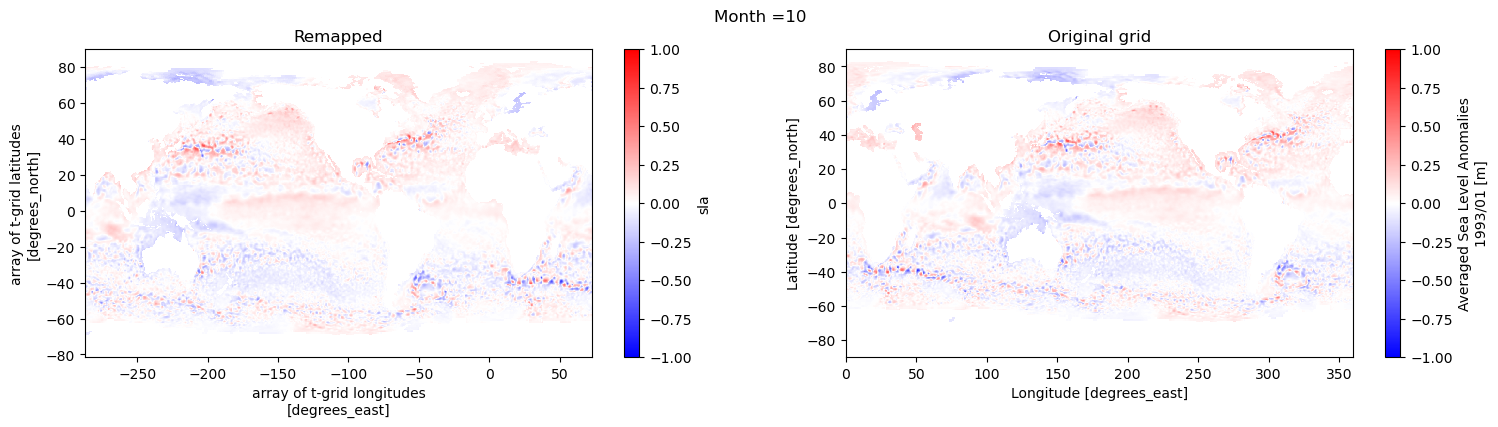

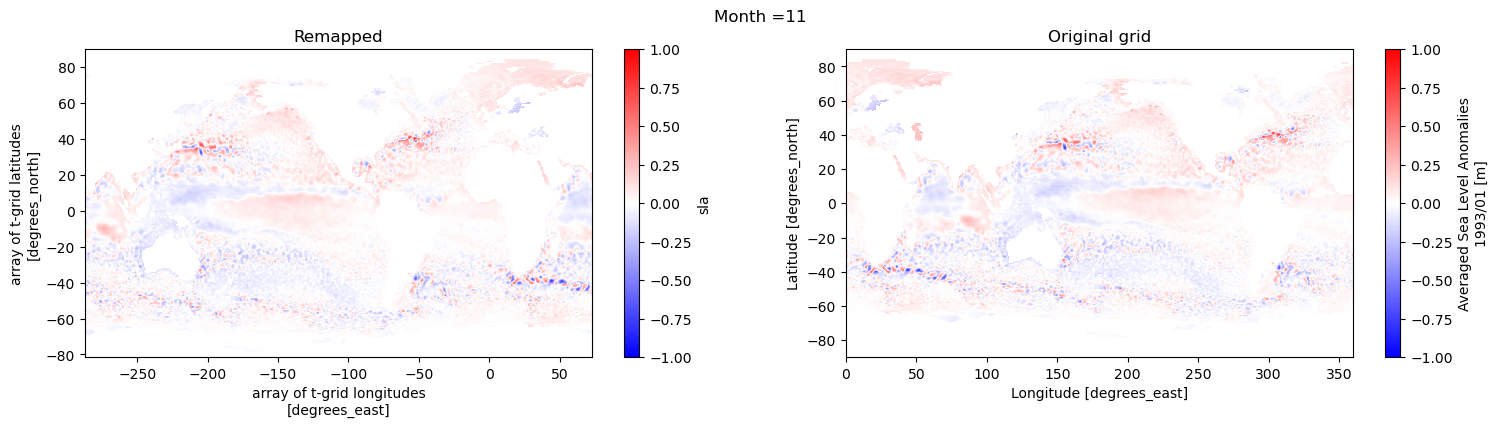

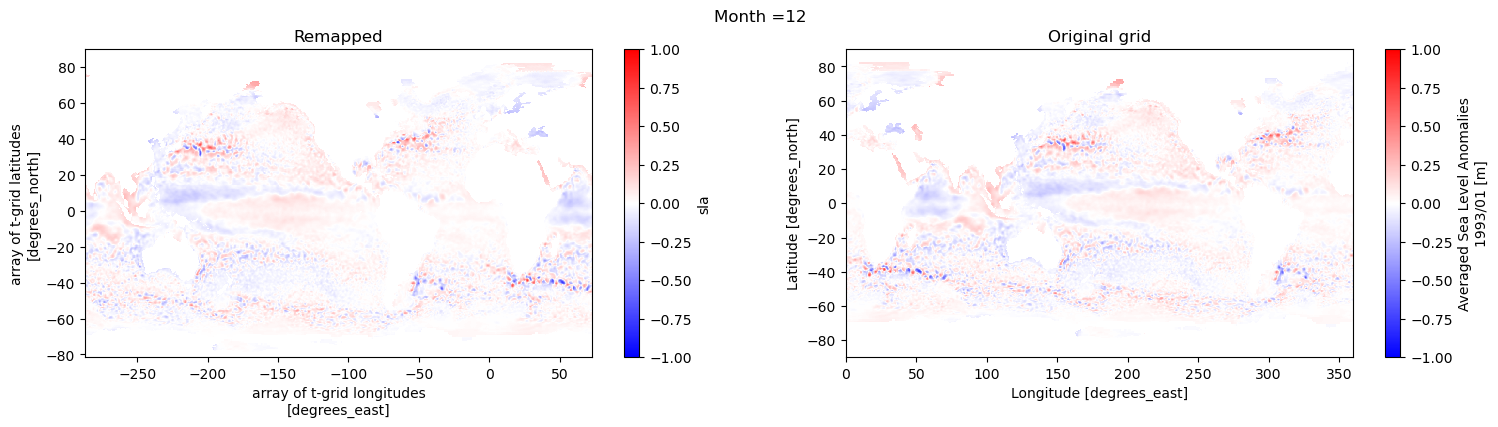

In [10]:
# visual inspection. Make sure original and remapped plots look similar
for t in range(12):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
  sla[t,:,:].plot.pcolormesh(x='geolon',y='geolat',ax=axes[0], vmin=-1,vmax=1, cmap='bwr')
  ds_in['sla'][t,:,:].plot.pcolormesh(ax=axes[1], vmin=-1,vmax=1, cmap='bwr')
  axes[0].set_title('Remapped')
  axes[1].set_title('Original grid')
  plt.suptitle('Month ='+ str(t+1))

In [11]:
# Global attrs
sla.attrs['title'] = 'Averaged Sea Level Anomalies remapped to tx2_3'
sla.attrs['comment'] = 'Monthly Mean of Sea Level Anomalies referenced to the [1993, 2012] period'
sla.attrs['references'] = 'http://www.aviso.altimetry.fr'
sla.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
sla.attrs['date'] = today
sla.attrs['infile'] = infile
sla.attrs['url'] = 'https://github.com/NCAR/tx2_3/aviso'
# save
fname = 'aviso_msla_to_tx2_3v3_{}.nc'.format(today)
sla.to_netcdf(fname)

### Absolute Dynamic Topography

In [12]:
infile = '/glade/campaign/cgd/oce/datasets/obs/aviso/mean_sea_level/monthly/*nc'
ds_in = xr.open_mfdataset(infile)
ds_in

/glade/derecho/scratch/gmarques/tmp/ipykernel_48164/2040787700.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_in = xr.open_mfdataset(infile)


<xarray.Dataset> Size: 6GB
Dimensions:    (time: 96, latitude: 720, longitude: 1440, nv: 2)
Coordinates:
  * time       (time) datetime64[ns] 768B 1993-01-16 ... 2000-12-16
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
  * nv         (nv) int32 8B 0 1
Data variables:
    adt        (time, latitude, longitude) float64 796MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    crs        (time) int32 384B -2147483647 -2147483647 ... -2147483647
    err        (time, latitude, longitude) float64 796MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    lat_bnds   (time, latitude, nv) float32 553kB dask.array<chunksize=(1, 50, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, nv) float32 1MB dask.array<chunksize=(1, 50, 2), meta=np.ndarray>
    sla        (time, latitude, longitude) float64 796MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    ugos       (time, latitude, longitude) float64 796MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    ugosa      (time, latitude, longitude) float64 796MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    vgos       (time, latitude, longitude) float64 796MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    vgosa      (time, latitude, longitude) float64 796MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               1993-01-01T00:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             1993-01-01T00:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    NCO:                             netCDF Operators version 5.1.4 (Homepage...

In [13]:
ds_ann =  weighted_temporal_mean(ds_in, 'adt')
ds_ann

<xarray.DataArray (time: 8, latitude: 720, longitude: 1440)> Size: 66MB
dask.array<truediv, shape=(8, 720, 1440), dtype=float64, chunksize=(1, 50, 50), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 64B 1993-01-01 1994-01-01 ... 2000-01-01
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Attributes:
    comment:        The absolute dynamic topography is the sea surface height...
    grid_mapping:   crs
    units:          m
    cell_methods:   time: mean
    axis:           T
    long_name:      Time
    standard_name:  time

In [14]:
ds_mean = ds_ann.mean('time').compute()
ds_mean

<xarray.DataArray (latitude: 720, longitude: 1440)> Size: 8MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(720, 1440))
Coordinates:
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Attributes:
    comment:        The absolute dynamic topography is the sea surface height...
    grid_mapping:   crs
    units:          m
    cell_methods:   time: mean
    axis:           T
    long_name:      Time
    standard_name:  time

In [15]:
def regrid_ssh(ds_in, ds_out, method='bilinear'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
       # filename="weights.nc",
       # reuse_weights=True,
        periodic=True,
    )
    fld_out = regrid(ds_in)
    return fld_out

In [16]:
adt = regrid_ssh(ds_mean, ds_out).rename('adt')
adt

<xarray.DataArray 'adt' (yh: 480, xh: 540)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(480, 540))
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  bilinear

In [17]:
# add coordinates
adt = adt.assign_coords(geolat=ds_out.lat, geolon=ds_out.lon)
adt

<xarray.DataArray 'adt' (yh: 480, xh: 540)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(480, 540))
Coordinates:
    geolat   (yh, xh) float64 2MB -81.56 -81.56 -81.56 ... 50.27 50.11 49.99
    geolon   (yh, xh) float64 2MB -286.7 -286.0 -285.3 ... 72.97 72.98 73.0
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  bilinear

Text(0.5, 0.98, 'Mean')

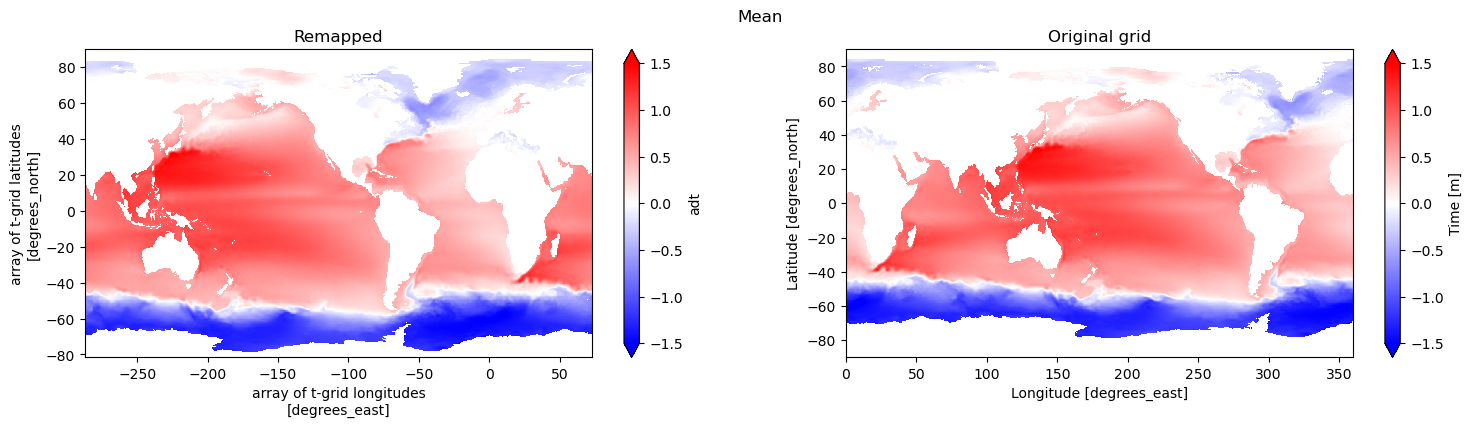

In [18]:
# visual inspection. Make sure original and remapped plots look similar
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
adt[:,:].plot.pcolormesh(x='geolon',y='geolat',ax=ax[0], vmin=-1.5,
                         vmax=1.5, cmap='bwr')
ds_mean[:,:].plot.pcolormesh(ax=ax[1], vmin=-1.5,
                                  vmax=1.5, cmap='bwr')
ax[0].set_title('Remapped')
ax[1].set_title('Original grid')
plt.suptitle('Mean')

In [19]:
# Global attrs
adt.attrs['title'] = 'Absolute dynamic topography remapped to tx2_3'
adt.attrs['comment'] = 'Monthly Mean Absolute dynamic topography'
adt.attrs['references'] = 'http://www.aviso.altimetry.fr'
adt.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
adt.attrs['date'] = today
adt.attrs['infile'] = infile
adt.attrs['url'] = 'https://github.com/NCAR/tx2_3/aviso'
# save
fname = 'aviso_adt_to_tx2_3v3_{}.nc'.format(today)
adt.to_netcdf(fname)